Run this notebook for sim = 0, 1, 2, ..., 9 to fit the 10 simulated images.

In [1]:
sim = 0

In [2]:
import numpy as np
import corner
import astropy.io.fits as pyfits
import matplotlib.pyplot as plt

# lenstronomy imports
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LensModel.lens_model import LensModel
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Util import kernel_util
import lenstronomy.Util.util as util

np.random.seed(40)

In [3]:
data_image_set = np.load("sim_image_noisy_set.npy")
data_image = data_image_set[sim]

pb_sim = pyfits.getdata("..//fits//sim_noise1.pb.fits")
pb_sim = pb_sim[0][0]
pb_sim = np.nan_to_num(pb_sim)

psf_sim = pyfits.getdata("..//fits//sim_noise1.psf.fits")
psf_sim = psf_sim[0][0]
psf_sim=np.nan_to_num(psf_sim)

In [4]:
pb_cut = pb_sim[50:150, 50:150] * 0.9  # use a pb of values smaller than 1 to test the pb implementation
psf_pixel = psf_sim[150:351,150:351]

In [5]:
background_rms = 1e-4
exp_time = np.inf  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.035  #  pixel size in arcsec (area per pixel = deltaPix**2)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 201  # PSF kernel size (odd number required).

# initial input simulation
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, background_rms)
kwargs_data['ra_at_xy_0'] = -(50)*deltaPix
kwargs_data['dec_at_xy_0'] = -(50)*deltaPix
kwargs_data['antenna_primary_beam'] = pb_cut
kwargs_data['likelihood_method'] = 'interferometry_natwt'
kwargs_data['image_data'] = data_image

# generate the psf variables
kernel_cut = kernel_util.cut_psf(psf_pixel, kernel_size, normalisation=False)
kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix,
                    'kernel_point_source': kernel_cut, 'kernel_point_source_normalisation': False}
psf_class = PSF(**kwargs_psf)
data_class = ImageData(**kwargs_data)

kwargs_numerics = {'supersampling_convolution': False}

C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


In [6]:
single_band = [[kwargs_data, kwargs_psf, kwargs_numerics]]
kwargs_data_joint = {'multi_band_list': single_band, 'multi_band_type': 'multi-linear'}

lens_model_list = ['EPL','SHEAR']
source_model_list = ['SERSIC_ELLIPSE']
point_source_model_list = ['LENSED_POSITION']


kwargs_fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

kwargs_fixed_lens.append({})
kwargs_lens_init.append({'theta_E': 0.8,
   'gamma': 2.0,
   'e1': 0.3,
   'e2': -0.25,
   'center_x': -0.1,
   'center_y': -0.03})
kwargs_lens_sigma.append({'theta_E':0.3,'gamma': 0.1,'center_x': 0.3, 'center_y': 0.3,'e1': 0.3, 'e2': 0.3})
kwargs_lower_lens.append({'theta_E':0.5,'gamma': 1.5,'center_x': -0.8, 'center_y': -0.8,'e1': -0.5, 'e2': -0.5})
kwargs_upper_lens.append({'theta_E': 1.2,'gamma': 2.5,'center_x': 0.8, 'center_y': 0.8,'e1': 0.5, 'e2': 0.5})

kwargs_fixed_lens.append({'ra_0': 0, 'dec_0': 0})
kwargs_lens_init.append({'gamma1': -0.01, 'gamma2': -0.1 })
kwargs_lens_sigma.append({'gamma1': 0.2, 'gamma2': 0.2 })
kwargs_lower_lens.append({'gamma1': -0.4, 'gamma2': -0.4 })
kwargs_upper_lens.append({'gamma1': 0.4, 'gamma2': 0.4 })

lens_params = [kwargs_lens_init, kwargs_lens_sigma, kwargs_fixed_lens, kwargs_lower_lens, kwargs_upper_lens]


kwargs_fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

kwargs_fixed_source.append({})
kwargs_source_init.append({
   'R_sersic': 0.1,
   'n_sersic': 1.2,
   'e1': -0.03,
   'e2': 0.1,
   'center_x': -0.02,
   'center_y': -0.09})
kwargs_source_sigma.append({
 'R_sersic': 0.05,
 'n_sersic': 0.2,
 'e1': 0.3,
 'e2': 0.3,
 'center_x': 0.3,
 'center_y': 0.3})
kwargs_lower_source.append({
 'R_sersic': 0.03,
 'n_sersic': 0.5,
 'e1': -0.5,
 'e2': -0.5,
 'center_x': -0.8,
 'center_y': -0.8})
kwargs_upper_source.append({
 'R_sersic': 0.5,
 'n_sersic': 5,
 'e1': 0.5,
 'e2': 0.5,
 'center_x': 0.8,
 'center_y': 0.8})

source_params = [kwargs_source_init, kwargs_source_sigma, kwargs_fixed_source, kwargs_lower_source, kwargs_upper_source]


kwargs_fixed_ps = []
kwargs_ps_init = []
kwargs_ps_sigma = []
kwargs_lower_ps = []
kwargs_upper_ps = []

kwargs_fixed_ps.append({})
kwargs_ps_init.append({
   'ra_image': [0.09, 0.19, 0.64, -0.65],
   'dec_image': [-0.95, 0.70, -0.09, 0.12]})
kwargs_ps_sigma.append({
    'ra_image': [0.3]*4,
   'dec_image': [0.3]*4})
kwargs_lower_ps.append({
   'ra_image': [-1.7]*4,
   'dec_image': [-1.7]*4})
kwargs_upper_ps.append({
   'ra_image': [1.7]*4,
   'dec_image': [1.7]*4})

ps_params = [kwargs_ps_init, kwargs_ps_sigma, kwargs_fixed_ps, kwargs_lower_ps, kwargs_upper_ps]


kwargs_params = {'lens_model': lens_params,
                'source_model': source_params,
                'point_source_model': ps_params}

kwargs_model = {'lens_model_list': lens_model_list,
                'source_light_model_list': source_model_list,
                'point_source_model_list': point_source_model_list,
                'additional_images_list': [False],
                'fixed_magnification_list': [True]}
kwargs_likelihood = {}
kwargs_constraints = {'joint_source_with_point_source': [[0, 0]],
                      'num_point_source_list': [4],
                      'solver_type': 'PROFILE',}

from lenstronomy.Workflow.fitting_sequence import FittingSequence
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, mpi=False)

fitting_kwargs_list =[['PSO', {'sigma_scale': 0.99, 'n_particles': 200, 'n_iterations': 1000, 'threadCount': 1}],
                     ['MCMC', {'n_burn': 700, 'n_run': 300, 'n_walkers':100, 'sigma_scale': 0.02, 'threadCount':1}]]

In [7]:
chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()

C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(
C:\conda\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
  0%|          | 0/1000 [00:00<?, ?it/s]

Computing the PSO ...


C:\conda\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)
C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\LensModel\Profiles\epl.py:300: RuntimeWarning: invalid value encountered in power
  alpha = 2 / (1 + q) * (b / R) ** t * R_omega
 15%|█▌        | 152/1000 [19:48<1:50:28,  7.82s/it]


Converged after 152 iterations!
Best fit found:  13196.535939824424 [1.9910406388555029, -0.004969552646874098, -0.1555788419297579, 0.10641159199778644, 0.6973931536606662, -0.08440729983943138, 0.14078531821851378, 0.08649172717743908, 0.19333670171073536, 0.6456807208167932, -0.663345330589283, -0.9533446096854793, 0.7015536967707623, -0.08326628461396846, 0.11977177652968037]
2.643801650771196 reduced X^2 of best position
13196.535939824424 log likelihood
9983.0 effective number of data points
[{'theta_E': 0.8103367707953006, 'gamma': 1.9910406388555029, 'e1': 0.35349718613362086, 'e2': -0.3047271626451093, 'center_x': -0.09411091575524169, 'center_y': -0.02993377620000323}, {'gamma1': -0.004969552646874098, 'gamma2': -0.1555788419297579, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'R_sersic': 0.10641159199778644, 'n_sersic': 0.6973931536606662, 'e1': -0.08440729983943138, 'e2': 0.14078531821851378, 'center_x': -0.02318767909133919, 'center_y': -0.09200878835894666}] source res

100%|██████████| 1000/1000 [59:11<00:00,  3.55s/it]

Computing the MCMC...
Number of walkers =  100
Burn-in iterations:  700
Sampling iterations (in current run): 1000
3558.2077465057373 time taken for MCMC sampling


In [8]:
sampler_type, samples_mcmc, param_mcmc, dist_mcmc  = chain_list[-1]

In [9]:
param_mcmc

['gamma_lens0',
 'gamma1_lens1',
 'gamma2_lens1',
 'R_sersic_source_light0',
 'n_sersic_source_light0',
 'e1_source_light0',
 'e2_source_light0',
 'ra_image',
 'ra_image',
 'ra_image',
 'ra_image',
 'dec_image',
 'dec_image',
 'dec_image',
 'dec_image']

<ipython-input-10-99d9de907100>:3: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot.show()
<ipython-input-10-99d9de907100>:6: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot.show()


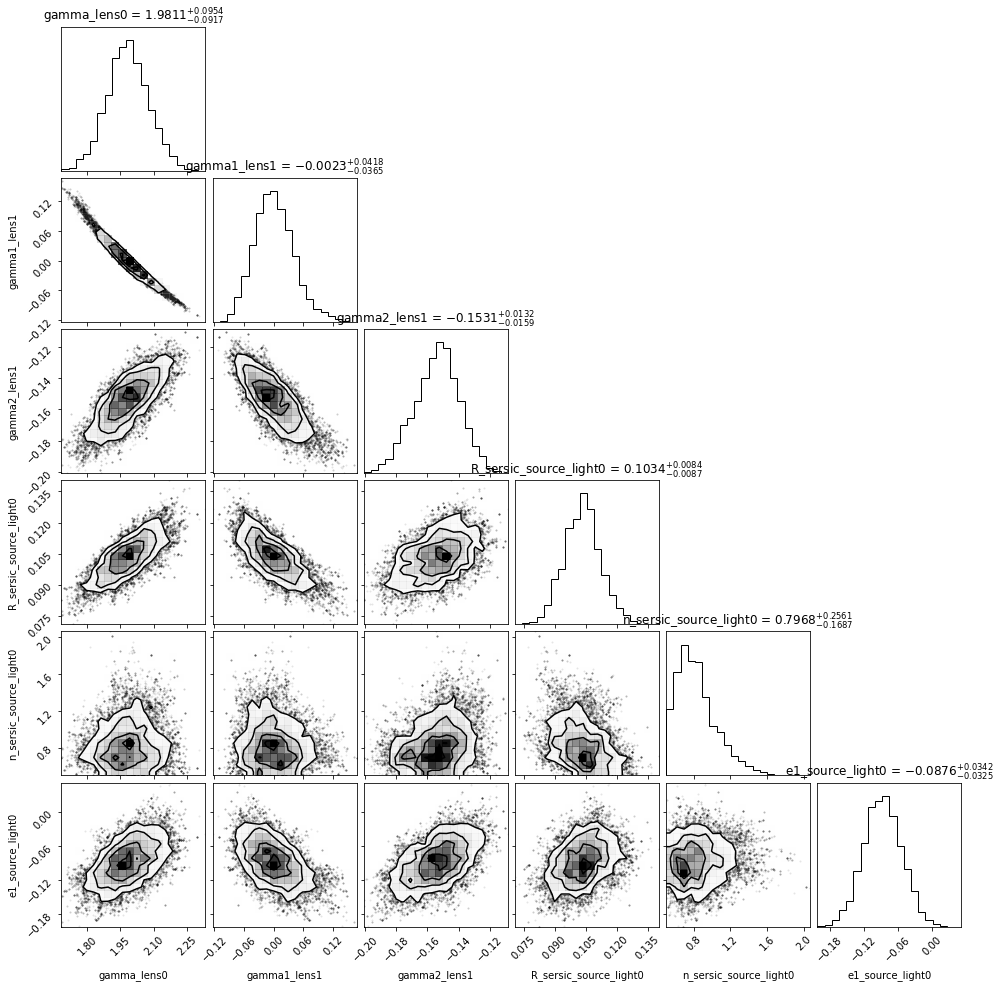

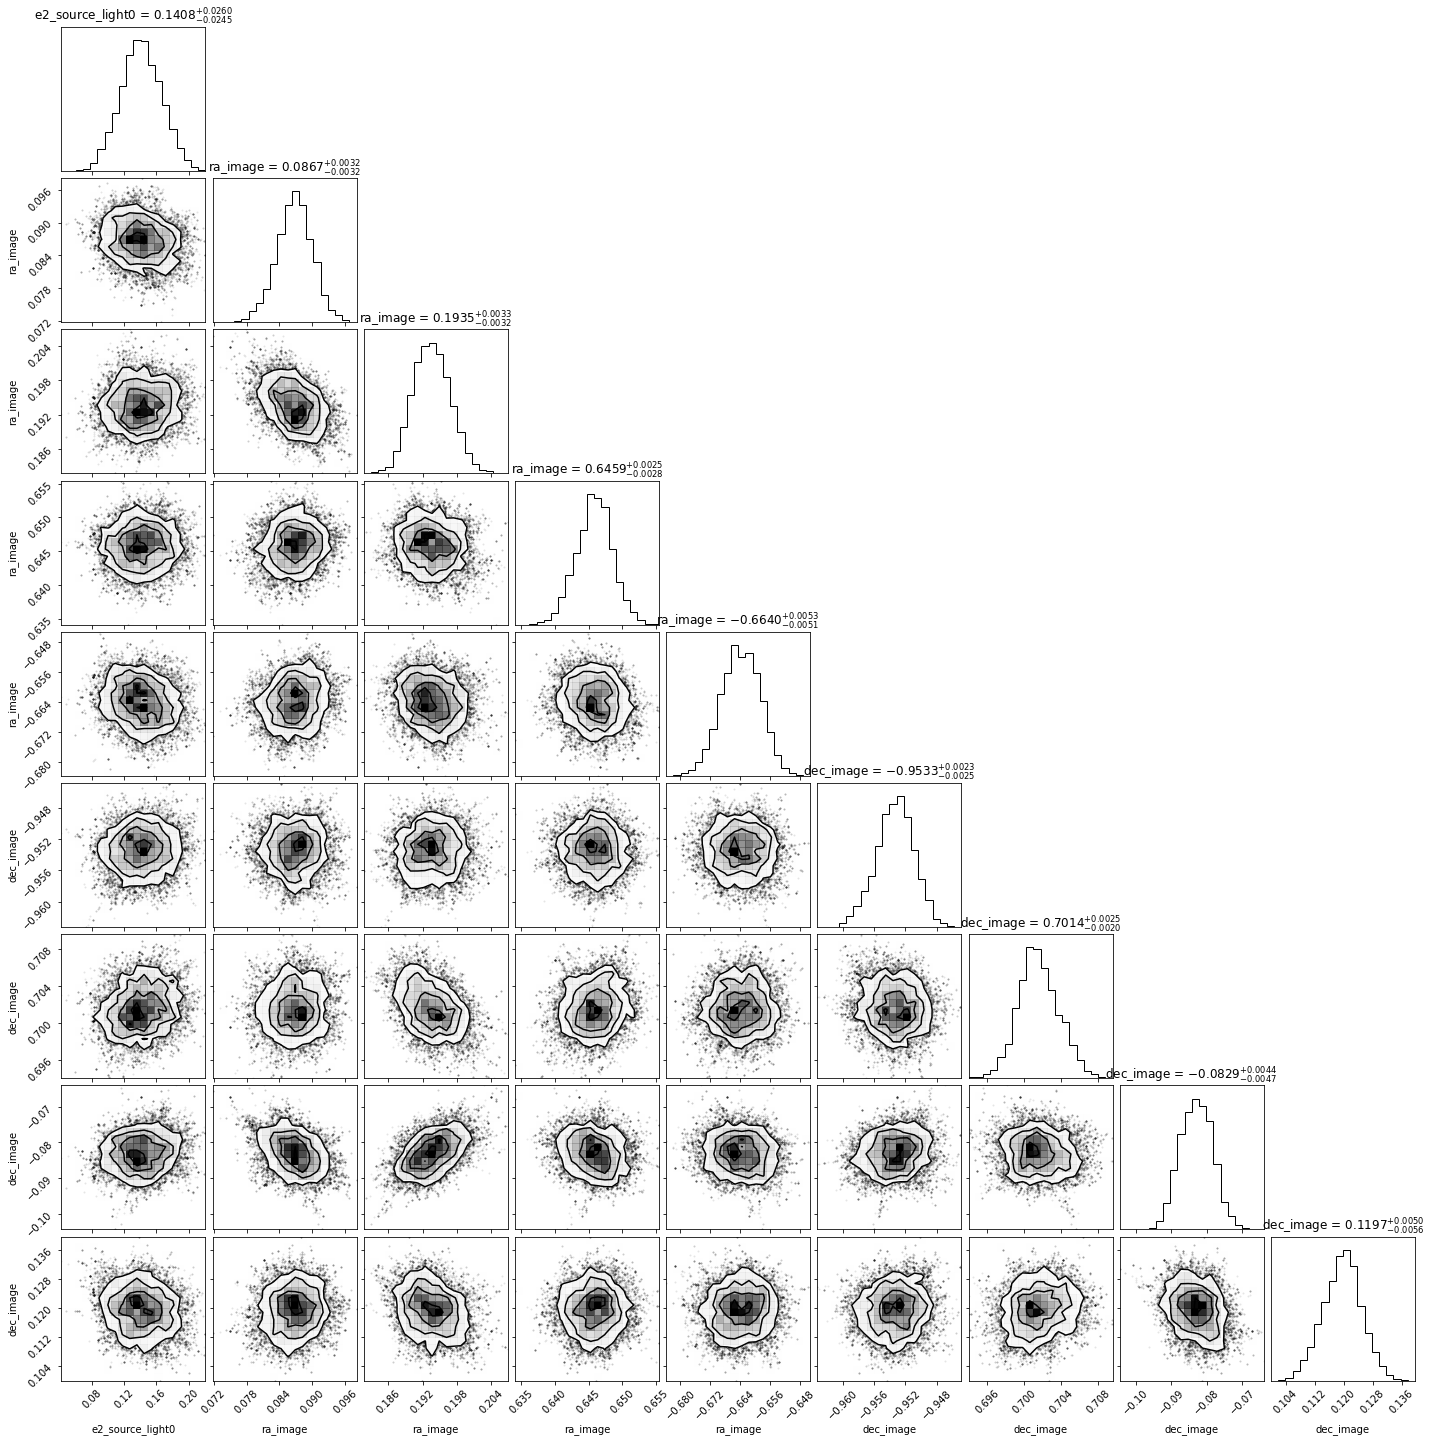

In [10]:
import corner
plot = corner.corner(samples_mcmc[:,:6], labels=param_mcmc[:6], show_titles=True, title_fmt = ".4f")
plot.show()

plot = corner.corner(samples_mcmc[:,6:], labels=param_mcmc[6:], show_titles=True, title_fmt = ".4f")
plot.show()

In [11]:
import h5py

In [12]:
with h5py.File('fitting results//chain_fitting_quadruply_imaged_quasar_sim' + str(sim) + '.h5', 'w') as fh5:
    fh5.create_dataset('chain', data=samples_mcmc, compression='gzip', compression_opts=9)